# Plano de parametro en el infinito para el metodo de Schroeder

Traduccion a Python del cuaderno de Mathematica `PlanoParametrosInfinitoSchroederNov24.nb`.


El metodo de Schroeder se aplica al polinomio $p(z) = (z^2-1)(z-\lambda)^n$.
Analizamos el mapa en el infinito $R(z) = 1 / S(1/z)$, con $S$ la transformacion iterativa de Schroeder.
Para cada parametro complejo $\lambda$ iteramos $R$ desde $z_0 = 0$ y detectamos a que raiz $\{1, -1, 1/\lambda\}$ converge.
Los graficos replican las regiones exploradas en el cuaderno original para $n = 1, 2, 3$.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

ROOT_LABELS = {0: "Sin convergencia", 1: "1/lambda", 2: "-1", 3: "1"}
COLORS = ListedColormap([
    "#000000",
    "#1f9e00",
    "#6c2dc7",
    "#ff75a0",
    "#ffffff",
])
NORM = BoundaryNorm([0, 1, 2, 3, 4], COLORS.N)


In [18]:
def schroeder_map(n):
    """Crea la transformacion R_n(z, lambda) del metodo de Schroeder."""
    if n == 1:
        def R(z, lam):
            lam2 = lam * lam
            z2 = z * z
            z3 = z2 * z
            z4 = z2 * z2
            num = 3 + z4 - 4*z*lam - 4*z3*lam + 2*z2*lam2 + 2*z4*lam2
            den = 4*z + lam - 10*z2*lam + z4*lam + 4*z3*lam2
            return num / den
    elif n == 2:
        def R(z, lam):
            lam2 = lam * lam
            z2 = z * z
            z3 = z2 * z
            z4 = z2 * z2
            num = 2 - 2*z*lam - 2*z3*lam + z2*(-1 + lam2) + z4*(1 + lam2)
            den = 2*z + lam - 6*z2*lam + z4*lam + 2*z3*lam2
            return num / den
    elif n == 3:
        def R(z, lam):
            lam2 = lam * lam
            z2 = z * z
            z3 = z2 * z
            z4 = z2 * z2
            num = 5 - 4*z*lam - 4*z3*lam + 2*z2*(-2 + lam2) + z4*(3 + 2*lam2)
            den = 4*z + 3*lam - 14*z2*lam + 3*z4*lam + 4*z3*lam2
            return num / den
    else:
        raise ValueError("Solo se implementan n = 1, 2, 3.")
    return R


BASE_SPEED_COLORS = {
    1: to_rgb("#1f9e00"),
    2: to_rgb("#6c2dc7"),
    3: to_rgb("#ff75a0"),
}
BACKGROUND_SPEED_COLOR = to_rgb("#050505")


def classify_root(z, lam, tol=1e-6):
    if abs(z - 1.0) < tol:
        return 3
    if abs(z + 1.0) < tol:
        return 2
    if abs(lam) > tol and abs(z - 1.0 / lam) < tol:
        return 1
    return 0


def parameter_grid(x_min, x_max, y_min, y_max, num_points):
    real = np.linspace(x_min, x_max, num_points)
    imag = np.linspace(y_max, y_min, num_points)
    real_grid, imag_grid = np.meshgrid(real, imag)
    return real_grid + 1j * imag_grid


def iterate_parameter_plane(iter_fn, lam_grid, max_iter=35, tol=1e-6, return_counts=False):
    labels = np.zeros(lam_grid.shape, dtype=np.uint8)
    counts = np.zeros(lam_grid.shape, dtype=np.uint16) if return_counts else None
    for index, lam in np.ndenumerate(lam_grid):
        z = 0.0j
        steps = 0
        label = classify_root(z, lam, tol)
        while label == 0 and steps < max_iter:
            steps += 1
            try:
                z = iter_fn(z, lam)
            except ZeroDivisionError:
                label = 0
                break
            if not (np.isfinite(z.real) and np.isfinite(z.imag)):
                label = 0
                break
            label = classify_root(z, lam, tol)
        labels[index] = label
        if return_counts:
            counts[index] = steps
    if return_counts:
        return labels, counts
    return labels


def tonalize_by_speed(labels, counts, max_iter, label_colors=None, background=None):
    if label_colors is None:
        label_colors = BASE_SPEED_COLORS
    if background is None:
        background = BACKGROUND_SPEED_COLOR
    rgb = np.zeros(labels.shape + (3,), dtype=float)
    rgb[...] = background
    tone = np.clip(counts.astype(float) / max_iter, 0.0, 1.0)
    tone = tone[..., None]
    for label, base in label_colors.items():
        mask = labels == label
        if not np.any(mask):
            continue
        base_rgb = np.array(base)
        rgb[mask] = base_rgb * (1.0 - tone[mask]) + tone[mask]
    return rgb


def plot_plane(data, x_min, x_max, y_min, y_max, ax=None, title=None, filename=None, dpi=300):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(
        data,
        origin="upper",
        extent=[x_min, x_max, y_min, y_max],
        cmap=COLORS,
        norm=NORM,
    )
    # ax.set_xlabel("Re(lambda)")
    # ax.set_ylabel("Im(lambda)")
    # if title:
    #     ax.set_title(title)
    ticks = [0.5, 1.5, 2.5, 3.5]
    cbar = plt.colorbar(im, ax=ax, ticks=ticks, fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([ROOT_LABELS[i] for i in range(4)])
    
    if filename:
        import os
        os.makedirs('img', exist_ok=True)
        filepath = os.path.join('img', filename)
        plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
        print(f"Imagen guardada en: {filepath}")
    
    return ax


def plot_speed_plane(labels, counts, x_min, x_max, y_min, y_max, max_iter, ax=None, title=None, filename=None, dpi=300):
    colors = tonalize_by_speed(labels, counts, max_iter)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(
        colors,
        origin="upper",
        extent=[x_min, x_max, y_min, y_max],
    )
    # ax.set_xlabel("Re(lambda)")
    # ax.set_ylabel("Im(lambda)")
    # if title:
    #     ax.set_title(title)
    
    if filename:
        import os
        os.makedirs('img', exist_ok=True)
        filepath = os.path.join('img', filename)
        plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
        print(f"Imagen guardada en: {filepath}")
    
    return ax


In [7]:
# Parametros de resolucion (reduce num_points para acelerar el calculo).
SCHROEDER_MAPS = {n: schroeder_map(n) for n in (1, 2, 3)}
CASE_PARAMS = {
    1: dict(x_min=-6.0, x_max=6.0, y_min=-6.0, y_max=6.0, num_points=512, max_iter=35),
    2: dict(x_min=-4.0, x_max=4.0, y_min=-4.0, y_max=4.0, num_points=512, max_iter=35),
    3: dict(x_min=-2.0, x_max=2.0, y_min=-2.0, y_max=2.0, num_points=512, max_iter=35),
}
CASE_PARAMS


{1: {'x_min': -6.0,
  'x_max': 6.0,
  'y_min': -6.0,
  'y_max': 6.0,
  'num_points': 512,
  'max_iter': 35},
 2: {'x_min': -4.0,
  'x_max': 4.0,
  'y_min': -4.0,
  'y_max': 4.0,
  'num_points': 512,
  'max_iter': 35},
 3: {'x_min': -2.0,
  'x_max': 2.0,
  'y_min': -2.0,
  'y_max': 2.0,
  'num_points': 512,
  'max_iter': 35}}

## Caso n = 1

Reproduce la ventana usada en el cuaderno original: Re(lambda) en [-2, 2] e Im(lambda) en [0, 6].


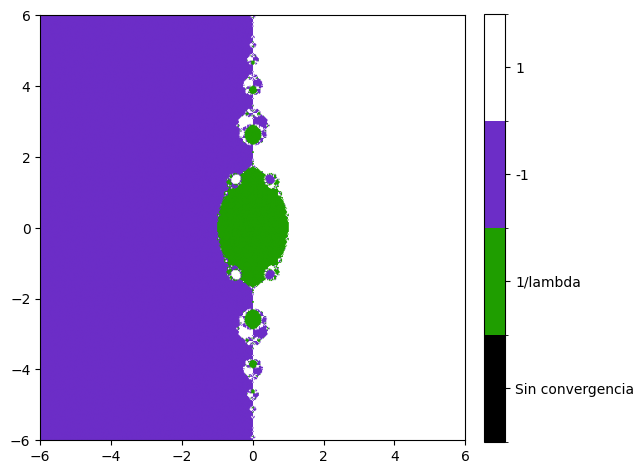

In [ ]:
params = CASE_PARAMS[1]
lam_grid = parameter_grid(
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["num_points"],
)
data = iterate_parameter_plane(SCHROEDER_MAPS[1], lam_grid, max_iter=params["max_iter"])
fig, ax = plt.subplots(figsize=(6, 8))
plot_plane(
    data,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    ax=ax,
    title="Plano de parametro para n = 1",
    filename="param_plane_n1.png",
)
plt.show()


#### Tonalidades segun la velocidad de convergencia

El color se aclara cuanto mas iteraciones son necesarias para detectar la raiz alcanzada.


Imagen guardada en: img\sch_infi_speed_plane_n1.png


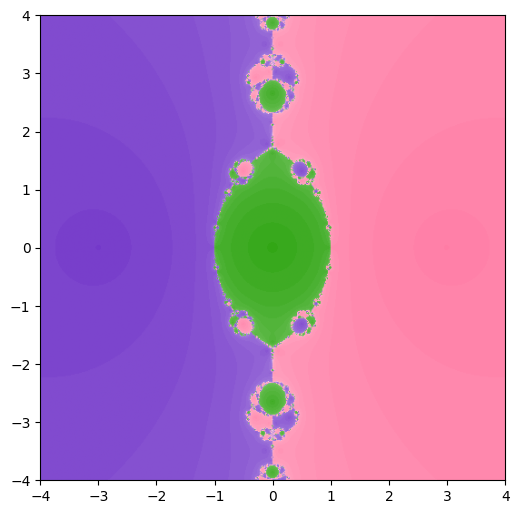

: 

In [ ]:
labels_speed_1, counts_speed_1 = iterate_parameter_plane(
    SCHROEDER_MAPS[1],
    lam_grid,
    max_iter=params["max_iter"],
    return_counts=True,
)
fig, ax = plt.subplots(figsize=(6, 8))
plot_speed_plane(
    labels_speed_1,
    counts_speed_1,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["max_iter"],
    ax=ax,
    title="Velocidad de convergencia n = 1",
    filename="sch_infi_speed_plane_n1.png",
)
plt.show()


## Caso n = 2

Ventana: Re(lambda) en [-4, 4] e Im(lambda) en [0, 4].


TypeError: plot_plane() got an unexpected keyword argument 'filename'

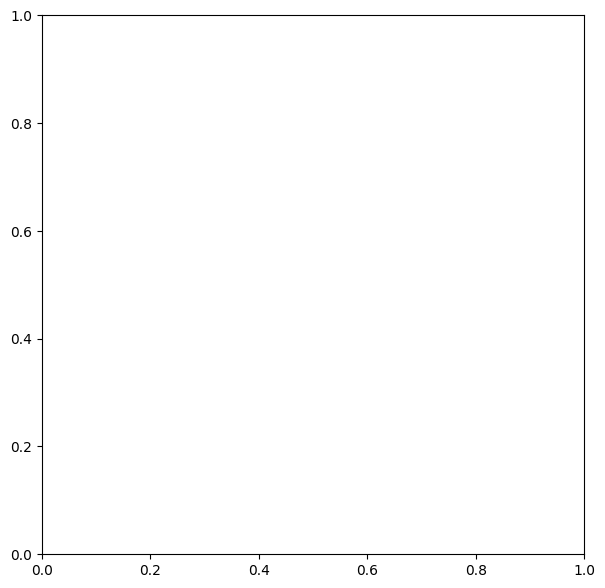

In [15]:
params = CASE_PARAMS[2]
lam_grid = parameter_grid(
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["num_points"],
)
data = iterate_parameter_plane(SCHROEDER_MAPS[2], lam_grid, max_iter=params["max_iter"])
fig, ax = plt.subplots(figsize=(7, 7))
plot_plane(
    data,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    ax=ax,
    title="Plano de parametro para n = 2",
    filename="sch_infi__n2.png",
)
plt.show()


#### Tonalidades segun la velocidad de convergencia

La misma pauta de colores permite resaltar las zonas de convergencia lenta.


TypeError: plot_speed_plane() got an unexpected keyword argument 'filename'

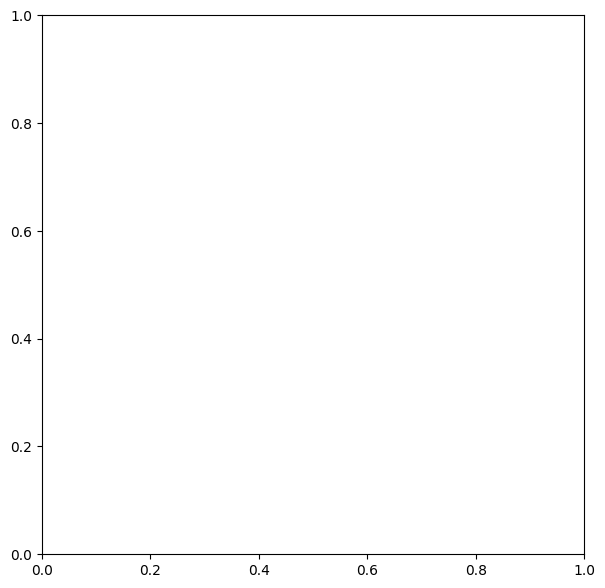

In [16]:
labels_speed_2, counts_speed_2 = iterate_parameter_plane(
    SCHROEDER_MAPS[2],
    lam_grid,
    max_iter=params["max_iter"],
    return_counts=True,
)
fig, ax = plt.subplots(figsize=(7, 7))
plot_speed_plane(
    labels_speed_2,
    counts_speed_2,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["max_iter"],
    ax=ax,
    title="Velocidad de convergencia n = 2",
    filename="sch_infi_speed_plane_n2.png",
)
plt.show()


## Caso n = 3

Ventana: Re(lambda) en [-4, 4] e Im(lambda) en [0, 2].


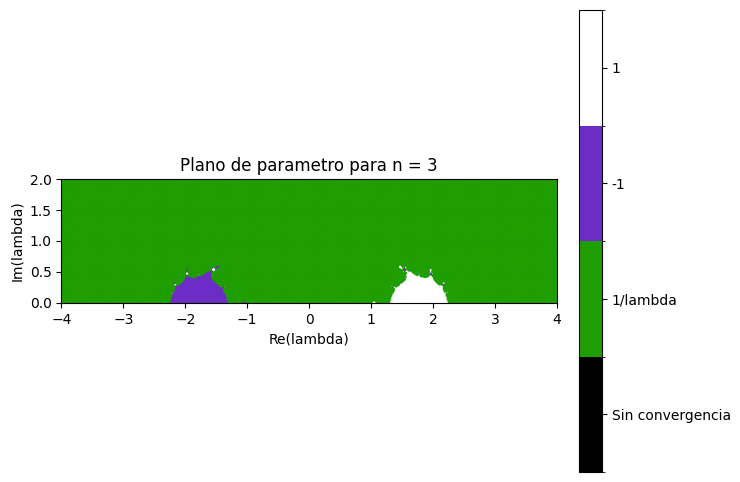

In [ ]:
params = CASE_PARAMS[3]
lam_grid = parameter_grid(
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["num_points"],
)
data = iterate_parameter_plane(SCHROEDER_MAPS[3], lam_grid, max_iter=params["max_iter"])
fig, ax = plt.subplots(figsize=(7, 6))
plot_plane(
    data,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    ax=ax,
    title="Plano de parametro para n = 3",
    filename="param_plane_n3.png",
)
plt.show()


#### Tonalidades segun la velocidad de convergencia

Aqui el degradado ayuda a localizar las fronteras mas rigidas de convergencia.


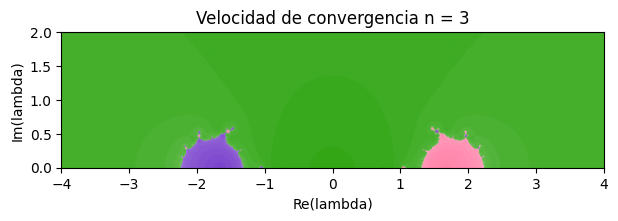

In [ ]:
labels_speed_3, counts_speed_3 = iterate_parameter_plane(
    SCHROEDER_MAPS[3],
    lam_grid,
    max_iter=params["max_iter"],
    return_counts=True,
)
fig, ax = plt.subplots(figsize=(7, 6))
plot_speed_plane(
    labels_speed_3,
    counts_speed_3,
    params["x_min"],
    params["x_max"],
    params["y_min"],
    params["y_max"],
    params["max_iter"],
    ax=ax,
    title="Velocidad de convergencia n = 3",
    filename="speed_plane_n3.png",
)
plt.show()


### Notas finales

- Reduce `num_points` si solo necesitas una exploracion rapida.
- Las funciones `schroeder_map` e `iterate_parameter_plane` permiten experimentar con otros valores de `n` repitiendo el calculo simbolico para obtener el mapa correspondiente.
